In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/Clean Data')
print(os.listdir())


Mounted at /content/drive
['df_census.csv', 'df_people.csv', 'df_crashes.csv', 'df_vehicles.csv', 'df_redlights.csv', 'df_speeding.csv', 'df_cameras.csv', 'catboost_info', 'injury_severity_model.pkl']


In [ ]:
import pandas as pd
df_crashes=pd.read_csv("df_crashes.csv")

# print(df_crashes.info())
# print(df_crashes.describe())


In [ ]:
import pandas as pd

df = df_crashes.copy()

# --- 1) Make the binary target ---
df["SEVERE_BIN"] = ((df["INJURIES_FATAL"] > 0) | (df["INJURIES_INCAPACITATING"] > 0)).astype(int)

# Quick sanity check on class balance
pos = df["SEVERE_BIN"].sum()
neg = (1 - df["SEVERE_BIN"]).sum()
print(f"Severe=1: {pos:,}  |  Non-severe=0: {neg:,}  |  Pos-rate: {pos/len(df):.4%}")

# --- 2) Drop outcome leakage + identifiers ---
leakage_cols = [
    # direct outcomes / near-outcomes
    "INJURIES_TOTAL","INJURIES_FATAL","INJURIES_INCAPACITATING",
    "INJURIES_NON_INCAPACITATING","INJURIES_REPORTED_NOT_EVIDENT",
    "INJURIES_NO_INDICATION","MOST_SEVERE_INJURY","DAMAGE",
    # timestamps/IDs/free-text not meant for modeling
    "CRASH_RECORD_ID","CRASH_DATE","DATE_POLICE_NOTIFIED",
    "STREET_NO","STREET_NAME"
]

# keep causes for now (they are predictive and available in reports);


X = df.drop(columns=leakage_cols + ["SEVERE_BIN"])
y = df["SEVERE_BIN"]

# ---Remove BEAT_OF_OCCURRENCE ---
if "BEAT_OF_OCCURRENCE" in X.columns:
    X = X.drop(columns=["BEAT_OF_OCCURRENCE"])

# ---Convert time & region columns to categorical ---
cat_time_cols = ["CRASH_HOUR", "CRASH_DAY_OF_WEEK", "CRASH_MONTH", "zipcode"]

# Fill missing zipcodes with a placeholder (string) before converting
X["zipcode"] = X["zipcode"].fillna("unknown").astype(str)

for col in cat_time_cols:
    X[col] = X[col].astype("category")


# copy
df_model = X.copy()

# -Numeric, binary, and categorical base features ---
numeric_cols = [
    'POSTED_SPEED_LIMIT','NUM_UNITS','LATITUDE','LONGITUDE'
]
binary_cols = ['INTERSECTION_RELATED_I','HIT_AND_RUN_I']
cat_cols = [
    'TRAFFIC_CONTROL_DEVICE','DEVICE_CONDITION','WEATHER_CONDITION','LIGHTING_CONDITION',
    'FIRST_CRASH_TYPE','TRAFFICWAY_TYPE','ALIGNMENT','ROADWAY_SURFACE_COND',
    'ROAD_DEFECT','REPORT_TYPE','CRASH_TYPE','PRIM_CONTRIBUTORY_CAUSE',
    'SEC_CONTRIBUTORY_CAUSE','STREET_DIRECTION','CRASH_HOUR','CRASH_DAY_OF_WEEK',
    'CRASH_MONTH','zipcode'
]

# -Feature engineering ---
# Weekend indicator
df_model['IS_WEEKEND'] = df_model['CRASH_DAY_OF_WEEK'].apply(lambda x: 1 if int(x) >= 6 else 0)

# Nighttime indicator
df_model['IS_NIGHT'] = df_model['CRASH_HOUR'].apply(lambda x: 1 if (int(x) <= 6) or (int(x) >= 20) else 0)

# Rush hour indicator
df_model['RUSH_HOUR'] = df_model['CRASH_HOUR'].apply(lambda x: 1 if (7 <= int(x) <= 9) or (16 <= int(x) <= 18) else 0)

# Hazardous weather indicator — broad list of risky types
hazardous_weather = [
    'RAIN', 'SNOW', 'FOG/SMOKE/HAZE', 'FREEZING RAIN/DRIZZLE',
    'SLEET/HAIL', 'BLOWING SNOW', 'BLOWING SAND, SOIL, DIRT',
    'SEVERE CROSS WIND GATE'
]
df_model['IS_RAIN_SNOW'] = df_model['WEATHER_CONDITION'].apply(
    lambda w: 1 if str(w).upper() in hazardous_weather else 0
)

# High-speed zone indicator
df_model['HIGH_SPEED_ZONE'] = df_model['POSTED_SPEED_LIMIT'].apply(lambda s: 1 if s >= 40 else 0)

# --- Final engineered feature list ---
engineered_cols = ['IS_WEEKEND','IS_NIGHT','RUSH_HOUR','IS_RAIN_SNOW','HIGH_SPEED_ZONE']

# ---Final column groups ---
numeric_cols_final = numeric_cols + ['HIGH_SPEED_ZONE']
binary_cols_final = binary_cols + ['IS_WEEKEND','IS_NIGHT','RUSH_HOUR','IS_RAIN_SNOW']
categorical_cols_final = cat_cols

print(f"Numeric columns ({len(numeric_cols_final)}):", numeric_cols_final)
print(f"Binary columns ({len(binary_cols_final)}):", binary_cols_final)
print(f"Categorical columns ({len(categorical_cols_final)}):", categorical_cols_final)
print("\n Total final features:", len(numeric_cols_final) + len(binary_cols_final) + len(categorical_cols_final))
print("DataFrame shape:", df_model.shape)
df_model.head()




Severe=1: 15,791  |  Non-severe=0: 933,319  |  Pos-rate: 1.6638%
Numeric columns (5): ['POSTED_SPEED_LIMIT', 'NUM_UNITS', 'LATITUDE', 'LONGITUDE', 'HIGH_SPEED_ZONE']
Binary columns (6): ['INTERSECTION_RELATED_I', 'HIT_AND_RUN_I', 'IS_WEEKEND', 'IS_NIGHT', 'RUSH_HOUR', 'IS_RAIN_SNOW']
Categorical columns (18): ['TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_DIRECTION', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'zipcode']

 Total final features: 29
DataFrame shape: (949110, 29)


,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,...,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,zipcode,IS_WEEKEND,IS_NIGHT,RUSH_HOUR,IS_RAIN_SNOW,HIGH_SPEED_ZONE
0,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,RAIN,"DARKNESS, LIGHTED ROAD",REAR TO FRONT,FOUR WAY,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,3,10,41.968643,-87.698492,60625.0,0,1,0,1,0
1,30,NO CONTROLS,NO CONTROLS,OTHER,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,NOT DIVIDED,STRAIGHT AND LEVEL,OTHER,NO DEFECTS,...,3,10,41.826667,-87.689679,60632.0,0,1,0,0,0
2,25,STOP SIGN/FLASHER,UNKNOWN,RAIN,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,T-INTERSECTION,STRAIGHT AND LEVEL,WET,UNKNOWN,...,3,10,41.885533,-87.759074,60644.0,0,1,0,1,0
3,25,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,ONE-WAY,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,3,10,41.823030,-87.621437,60653.0,0,1,0,0,0
4,35,NO CONTROLS,NO CONTROLS,CLEAR,DARKNESS,SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,WET,NO DEFECTS,...,2,10,41.828208,-87.670489,60609.0,0,1,0,0,0


<h1>Using Resampling</h1>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve
)
import numpy as np
import pandas as pd

# ================================================================
# 0) DATA SPLIT (same for all experiments)
# ================================================================
X = df_model.copy()
y = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Original train severe rate:", y_train.mean())
print("Original test severe rate:", y_test.mean())
print("------------------------------------------------------")

# ================================================================
# Function to run experiment for a given resample ratio
# ================================================================
def run_experiment(target_ratio):

    print(f"\n==================== Testing Resample Ratio: {target_ratio*100:.0f}% ====================")

    # -----------------------------------
    # Resample minority
    train_df = X_train.copy()
    train_df["label"] = y_train

    minor = train_df[train_df["label"] == 1]
    major = train_df[train_df["label"] == 0]

    target_minority_size = int(target_ratio * len(major))

    minor_up = resample(
        minor,
        replace=True,
        n_samples=target_minority_size,
        random_state=42
    )

    train_balanced = pd.concat([major, minor_up]).sample(frac=1, random_state=42)

    X_train_bal = train_balanced.drop("label", axis=1)
    y_train_bal = train_balanced["label"]

    print("Balanced train severe rate:", y_train_bal.mean())
    print("Balanced train shape:", X_train_bal.shape)

    # -----------------------------------
    # Convert categoricals
    for col in categorical_cols_final:
        X_train_bal[col] = X_train_bal[col].astype("category")
        X_test[col] = X_test[col].astype("category")

    cat_features = [c for c in X_train_bal.columns if str(X_train_bal[c].dtype) == "category"]

    # -----------------------------------
    # Train LightGBM
    lgbm = LGBMClassifier(
        objective="binary",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=127,
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        class_weight=None,
        n_jobs=-1
    )

    lgbm.fit(
        X_train_bal, y_train_bal,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
        categorical_feature=cat_features,
        callbacks=[early_stopping(stopping_rounds=100)]
    )

    # -----------------------------------
    # Evaluate
    probs = lgbm.predict_proba(X_test)[:, 1]

    # Compute F2 threshold
    prec, rec, thresh = precision_recall_curve(y_test, probs)
    beta = 2.0
    f2 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-12)
    best_idx = np.nanargmax(f2)
    best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

    # Predict
    pred_best = (probs >= best_thresh).astype(int)

    # Output results
    print(f"Best F2 Threshold: {best_thresh:.3f}")
    print("Classification Report:")
    print(classification_report(y_test, pred_best, digits=3))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred_best))

    # Return metrics for comparison
    return {
        "ratio": target_ratio,
        "threshold": best_thresh,
        "precision_1": classification_report(y_test, pred_best, output_dict=True)["1"]["precision"],
        "recall_1": classification_report(y_test, pred_best, output_dict=True)["1"]["recall"],
        "f2_1": (5 * classification_report(y_test, pred_best, output_dict=True)["1"]["precision"] *
                    classification_report(y_test, pred_best, output_dict=True)["1"]["recall"]) /
                    (4 * classification_report(y_test, pred_best, output_dict=True)["1"]["precision"] +
                     classification_report(y_test, pred_best, output_dict=True)["1"]["recall"] + 1e-12)
    }

# ================================================================
# 3) RUN EXPERIMENTS FOR MULTIPLE RESAMPLING RATIOS
# ================================================================
ratios = [0.10, 0.20, 0.25, 0.30]

results = []

for r in ratios:
    res = run_experiment(r)
    results.append(res)

# ================================================================
# 4) PRINT SUMMARY
# ================================================================
print("\n===================== SUMMARY =====================")
for r in results:
    print(f"Ratio={r['ratio']*100:.0f}% | Thresh={r['threshold']:.3f} | Precision={r['precision_1']:.3f} | Recall={r['recall_1']:.3f} | F2={r['f2_1']:.3f}")

Original train severe rate: 0.016637955558365204
Original test severe rate: 0.016636638535048626
------------------------------------------------------

==================== Testing Resample Ratio: 10% ====================
Balanced train severe rate: 0.09090853747625773
Balanced train shape: (821320, 29)
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=

In [ ]:
# training the model using class weight balanced

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve
)
import numpy as np
import pandas as pd

# ================================================================
# 0) DATA SPLIT (same for all experiments)
# ================================================================
X = df_model.copy()
y = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Original train severe rate:", y_train.mean())
print("Original test severe rate:", y_test.mean())
print("------------------------------------------------------")

# ================================================================
# Function to run experiment for a given resample ratio
# ================================================================
def run_experiment(target_ratio):

    print(f"\n==================== Testing Resample Ratio: {target_ratio*100:.0f}% ====================")

    # -----------------------------------
    # Resample minority
    train_df = X_train.copy()
    train_df["label"] = y_train

    minor = train_df[train_df["label"] == 1]
    major = train_df[train_df["label"] == 0]

    target_minority_size = int(target_ratio * len(major))

    minor_up = resample(
        minor,
        replace=True,
        n_samples=target_minority_size,
        random_state=42
    )

    train_balanced = pd.concat([major, minor_up]).sample(frac=1, random_state=42)

    X_train_bal = train_balanced.drop("label", axis=1)
    y_train_bal = train_balanced["label"]

    print("Balanced train severe rate:", y_train_bal.mean())
    print("Balanced train shape:", X_train_bal.shape)

    # -----------------------------------
    # Convert categoricals
    for col in categorical_cols_final:
        X_train_bal[col] = X_train_bal[col].astype("category")
        X_test[col] = X_test[col].astype("category")

    cat_features = [c for c in X_train_bal.columns if str(X_train_bal[c].dtype) == "category"]

    # -----------------------------------
    # Train LightGBM
    lgbm = LGBMClassifier(
        objective="binary",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=127,
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    lgbm.fit(
        X_train_bal, y_train_bal,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
        categorical_feature=cat_features,
        callbacks=[early_stopping(stopping_rounds=100)]
    )

    # -----------------------------------
    # Evaluate
    probs = lgbm.predict_proba(X_test)[:, 1]

    # Compute F2 threshold
    prec, rec, thresh = precision_recall_curve(y_test, probs)
    beta = 2.0
    f2 = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-12)
    best_idx = np.nanargmax(f2)
    best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

    # Predict
    pred_best = (probs >= best_thresh).astype(int)

    # Output results
    print(f"Best F2 Threshold: {best_thresh:.3f}")
    print("Classification Report:")
    print(classification_report(y_test, pred_best, digits=3))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred_best))

    # Return metrics for comparison
    return {
        "ratio": target_ratio,
        "threshold": best_thresh,
        "precision_1": classification_report(y_test, pred_best, output_dict=True)["1"]["precision"],
        "recall_1": classification_report(y_test, pred_best, output_dict=True)["1"]["recall"],
        "f2_1": (5 * classification_report(y_test, pred_best, output_dict=True)["1"]["precision"] *
                    classification_report(y_test, pred_best, output_dict=True)["1"]["recall"]) /
                    (4 * classification_report(y_test, pred_best, output_dict=True)["1"]["precision"] +
                     classification_report(y_test, pred_best, output_dict=True)["1"]["recall"] + 1e-12)
    }

# ================================================================
# 3) RUN EXPERIMENTS FOR MULTIPLE RESAMPLING RATIOS
# ================================================================
ratios = [0.10, 0.20, 0.25, 0.30]

results = []

for r in ratios:
    res = run_experiment(r)
    results.append(res)

# ================================================================
# 4) PRINT SUMMARY
# ================================================================
print("\n===================== SUMMARY =====================")
for r in results:
    print(f"Ratio={r['ratio']*100:.0f}% | Thresh={r['threshold']:.3f} | Precision={r['precision_1']:.3f} | Recall={r['recall_1']:.3f} | F2={r['f2_1']:.3f}")


Original train severe rate: 0.016637955558365204
Original test severe rate: 0.016636638535048626
------------------------------------------------------

==================== Testing Resample Ratio: 10% ====================
Balanced train severe rate: 0.09090853747625773
Balanced train shape: (821320, 29)
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=

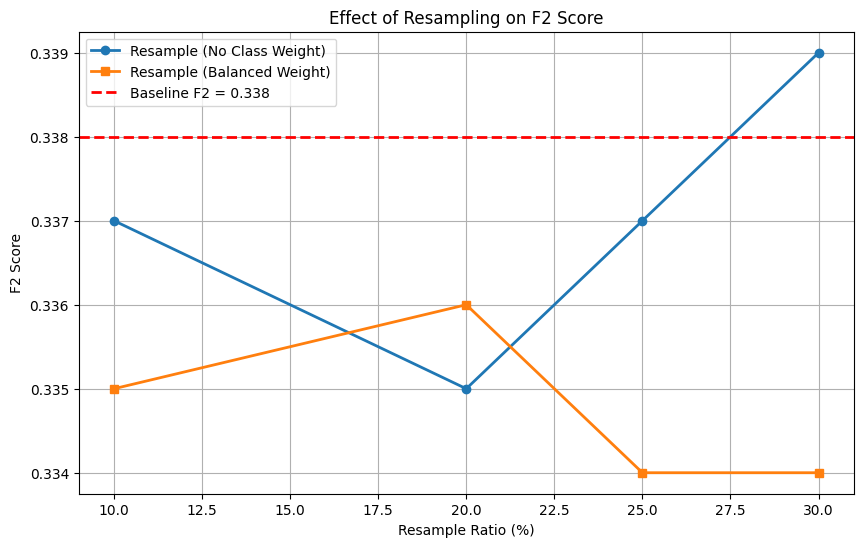

In [ ]:
import matplotlib.pyplot as plt

# baseline F2
baseline_f2 = 0.338   # your best model's F2

# resample ratios
ratios = [10, 20, 25, 30]

# F2 values from your results
f2_no_weight  = [0.337, 0.335, 0.337, 0.339]
f2_weighted   = [0.335, 0.336, 0.334, 0.334]

plt.figure(figsize=(10,6))

# plot both lines
plt.plot(ratios, f2_no_weight, marker='o', label="Resample (No Class Weight)", linewidth=2)
plt.plot(ratios, f2_weighted, marker='s', label="Resample (Balanced Weight)", linewidth=2)

# baseline line
plt.axhline(baseline_f2, color='red', linestyle='--', linewidth=2,
            label=f"Baseline F2 = {baseline_f2}")

plt.xlabel("Resample Ratio (%)")
plt.ylabel("F2 Score")
plt.title("Effect of Resampling on F2 Score")
plt.legend()
plt.grid(True)
plt.show()


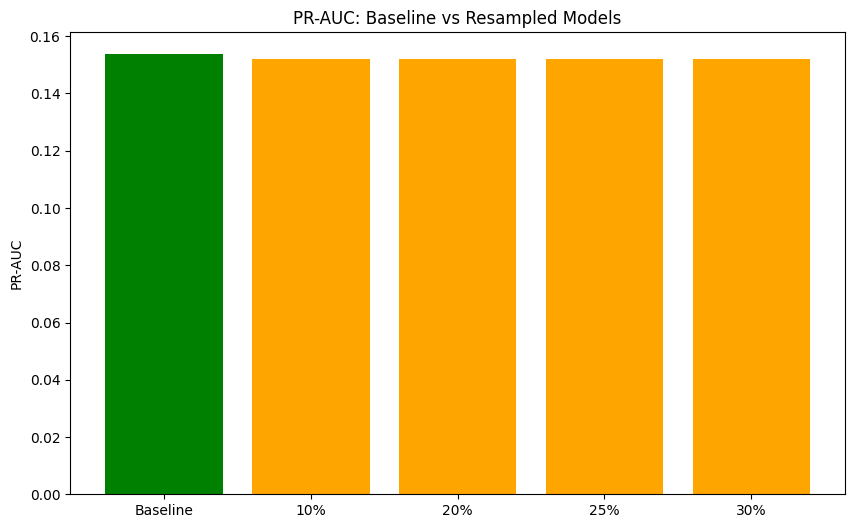

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(['Baseline','10%','20%','25%','30%'],
        [0.1537, 0.1520, 0.1522, 0.1521, 0.1520],
        color=['green','orange','orange','orange','orange'])

plt.ylabel("PR-AUC")
plt.title("PR-AUC: Baseline vs Resampled Models")
plt.show()


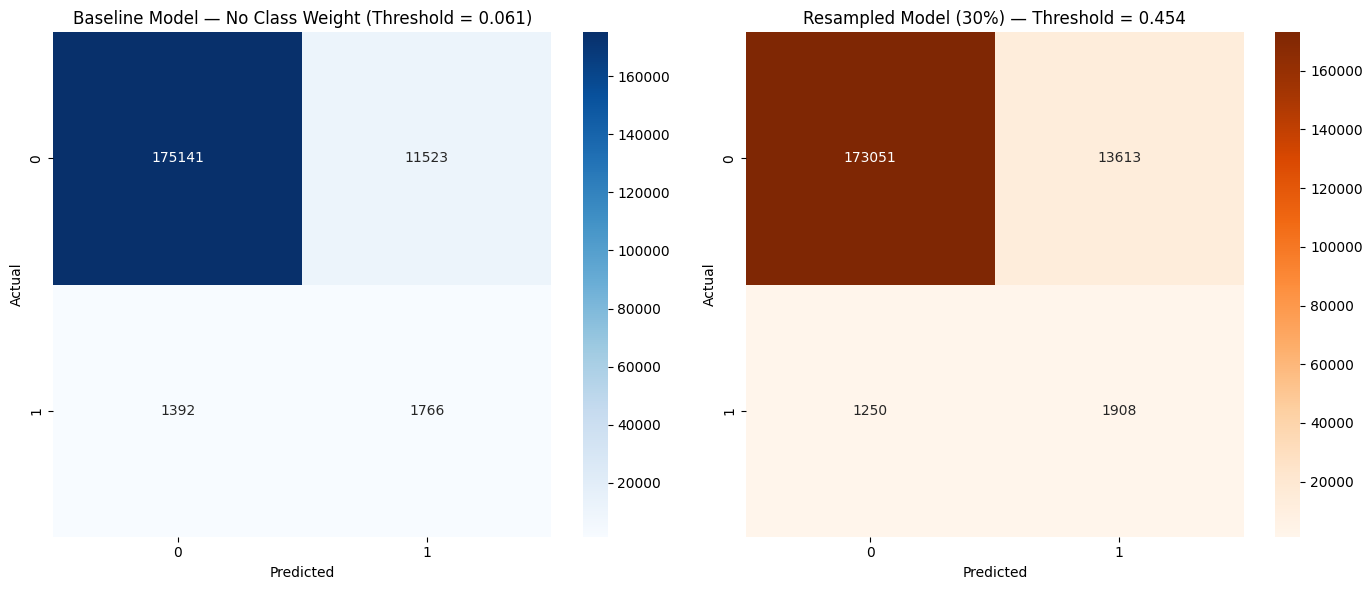

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ================================================
# Confusion matrices (from your results)
# ================================================
baseline_cm = np.array([[175141, 11523],
                        [  1392,  1766]])

resampled_cm = np.array([[173051, 13613],
                         [  1250,  1908]])

# ================================================
# Plotting side-by-side heatmaps
# ================================================
plt.figure(figsize=(14, 6))

# ---- Baseline ----
plt.subplot(1, 2, 1)
sns.heatmap(baseline_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Baseline Model — No Class Weight (Threshold = 0.061)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# ---- Resampled (30%) ----
plt.subplot(1, 2, 2)
sns.heatmap(resampled_cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Resampled Model (30%) — Threshold = 0.454")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


<P>The side-by-side confusion matrices show that resampling increases false positives without providing meaningful improvements to true positive detection. The baseline model maintains a better precision–recall balance, confirming that resampling does not offer any benefit for this case study.
</P>